# Homodimer Confidence Metric Diagnostic Notebook

**Purpose:** This notebook helps you understand *why* different confidence scores for a predicted protein complex (homodimer) from the AlphaFold Database (AFDB) agree or disagree.

**What is a homodimer?** A homodimer is a protein complex made of two identical copies of the same protein chain (chain A and chain B). AlphaFold can predict the 3D structure of such complexes.

**What are confidence scores?** AlphaFold and related tools compute several numbers that estimate how reliable the predicted structure is. This notebook computes five of them:
- **ipTM** – Overall confidence in chain positioning
- **ipSAE** – Stricter confidence using only well-predicted residues
- **pDockQ** – Structural plausibility (contact count + pLDDT)
- **pDockQ2** – Like pDockQ but also checks PAE at the interface
- **LIS** – Density of low-error inter-chain interactions

**No structural biology background required.** Every section includes a plain-language explanation before any code.

---
**Usage:** Set `ACCESSION_ID` in Section 1, then run all cells (Runtime → Run all).

In [ ]:
# Install required packages
# In Google Colab these are not pre-installed; locally they come from pyproject.toml / uv sync.
import subprocess, sys
subprocess.run(
    [sys.executable, '-m', 'pip', 'install', '-q', 'molviewspec'],
    check=False
)
print('Package check complete.')

In [26]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.gridspec import GridSpec
import seaborn as sns
import requests
import json
import warnings
import base64
from IPython.display import display, HTML, IFrame
warnings.filterwarnings('ignore')

sns.set_style('white')
plt.rcParams.update({
    'font.size': 12,
    'axes.labelsize': 12,
    'axes.titlesize': 13,
    'xtick.labelsize': 10,
    'ytick.labelsize': 10,
    'figure.dpi': 150,
})

# Consistent colour scheme (spec §7.1)
COLOUR_A = '#009688'   # teal  – chain A
COLOUR_B = '#FF7043'   # coral – chain B
COLOUR_IF = '#FFC107'  # amber – interface residues

print('Imports OK')

Imports OK


---
## Section 1 — Setup and Data Loading

**What happens here?**
We fetch all the raw data from the AlphaFold Database (AFDB) for one homodimer accession.

The AFDB stores:
- The **3D structure** in mmCIF format (atom positions for every residue)
- The **PAE matrix** — a grid of numbers where entry `[i, j]` = how uncertain AlphaFold is about the position of residue `i` given that residue `j` is aligned correctly (lower = better)
- The **pLDDT scores** — a per-residue confidence score (0–100, higher = better)

We parse all three into data structures we can analyse.

In [ ]:
# ── USER INPUT ──────────────────────────────────────────────────────────────
ACCESSION_ID = 'AF-0000000065889468'  # @param {type:"string"}
# ────────────────────────────────────────────────────────────────────────────
PAE_CUTOFF  = 10.0   # AFDB standard cutoff for ipSAE
DIST_CUTOFF =  8.0   # CB-CB contact cutoff (Angstroms)
LIS_CUTOFF  = 12.0   # PAE cutoff for LIS

# Set True to upload local files instead of fetching from AFDB
USE_LOCAL_FILE = False

In [ ]:
import ipywidgets as _widgets
from IPython.display import display as _display

if USE_LOCAL_FILE:
    _upload_cif   = _widgets.FileUpload(accept='.cif,.mmcif', multiple=False,
                                        description='mmCIF (required)')
    _upload_pae   = _widgets.FileUpload(accept='.json',       multiple=False,
                                        description='PAE JSON (optional)')
    _upload_plddt = _widgets.FileUpload(accept='.json',       multiple=False,
                                        description='pLDDT JSON (optional)')
    _display(_widgets.VBox([
        _widgets.HTML('<b>Upload local structure files, then run the next cell.</b>'),
        _upload_cif,
        _upload_pae,
        _upload_plddt,
    ]))
else:
    print('Online mode — files will be downloaded from AFDB.')

In [ ]:
if USE_LOCAL_FILE:
    # Build a minimal meta dict so downstream cells don't break
    meta = {
        'uniprotAccession': ACCESSION_ID,
        'cifUrl': '',
        'bcifUrl': '',
        'paeDocUrl': '',
        'plddtDocUrl': '',
    }
    print(f'Local file mode — skipping AFDB API for {ACCESSION_ID}')
else:
    # Fetch metadata from the AFDB API
    AFDB_API = f'https://alphafold.ebi.ac.uk/api/prediction/{ACCESSION_ID}'
    print(f'Fetching: {AFDB_API}')
    resp = requests.get(AFDB_API, timeout=30)
    resp.raise_for_status()
    entries = resp.json()
    if not entries:
        raise ValueError(f'No data found for {ACCESSION_ID}')
    meta = entries[0]
    print('Available fields:', sorted(meta.keys()))

In [ ]:
def _read_upload(widget):
    """Return bytes from a FileUpload widget, or None if nothing was uploaded."""
    if not widget.value:
        return None
    content = widget.value[0]['content']
    return bytes(content)


if USE_LOCAL_FILE:
    # ── Load structure from uploaded mmCIF ───────────────────────────────────
    _cif_bytes = _read_upload(_upload_cif)
    if _cif_bytes is None:
        raise ValueError('No mmCIF file uploaded — use the upload widget in the cell above.')
    cif_text = _cif_bytes.decode('utf-8', errors='replace')
    print(f'Loaded mmCIF  : {_upload_cif.value[0]["name"]}')

    # ── Load PAE (optional) ──────────────────────────────────────────────────
    _pae_bytes = _read_upload(_upload_pae)
    if _pae_bytes:
        pae_raw = json.loads(_pae_bytes)
        print(f'Loaded PAE    : {_upload_pae.value[0]["name"]}')
    else:
        pae_raw = None
        print('PAE file not uploaded — PAE-dependent analyses will be skipped.')

    # ── Load pLDDT (optional) ────────────────────────────────────────────────
    _plddt_bytes = _read_upload(_upload_plddt)
    if _plddt_bytes:
        plddt_raw = json.loads(_plddt_bytes)
        print(f'Loaded pLDDT  : {_upload_plddt.value[0]["name"]}')
    else:
        plddt_raw = None
        print('pLDDT file not uploaded — pLDDT analyses will be skipped.')

else:
    # ── Download structure (mmCIF) ────────────────────────────────────────────
    cif_url = meta['cifUrl']
    print(f'Downloading mmCIF: {cif_url}')
    cif_text = requests.get(cif_url, timeout=60).text

    # ── Download PAE JSON ─────────────────────────────────────────────────────
    pae_url = meta['paeDocUrl']
    print(f'Downloading PAE:   {pae_url}')
    pae_raw = requests.get(pae_url, timeout=60).json()

    # ── Download pLDDT JSON ───────────────────────────────────────────────────
    plddt_url = meta['plddtDocUrl']
    print(f'Downloading pLDDT: {plddt_url}')
    plddt_raw = requests.get(plddt_url, timeout=60).json()

print('All downloads complete.')

In [30]:
# ── Parse mmCIF (no BioPython required) ─────────────────────────────────────
def parse_mmcif_atoms(cif_text):
    """Return (records, col_idx) from the _atom_site loop in an mmCIF file."""
    lines = cif_text.split('\n')
    i = 0
    # Locate _atom_site loop
    while i < len(lines):
        if lines[i].strip() == 'loop_':
            j = i + 1
            while j < len(lines) and not lines[j].strip():
                j += 1
            if j < len(lines) and lines[j].strip().startswith('_atom_site.'):
                break
        i += 1
    else:
        raise ValueError('No _atom_site loop found in mmCIF')

    i += 1  # skip 'loop_' line
    columns = []
    while i < len(lines) and lines[i].strip().startswith('_atom_site.'):
        columns.append(lines[i].strip().split('_atom_site.')[1].strip())
        i += 1

    col_idx = {c: k for k, c in enumerate(columns)}
    n_cols = len(columns)

    records = []
    while i < len(lines):
        line = lines[i].strip()
        if not line or line.startswith('#'):
            i += 1
            continue
        if line.startswith('_') or line == 'loop_':
            break
        parts = line.split()
        if len(parts) >= n_cols:
            records.append(parts[:n_cols])
        i += 1
    return records, col_idx


def extract_cb_coords(records, col_idx):
    """Extract CB (or CA for GLY) coords, pLDDT, and residue info per chain."""
    cb_data = {}  # (chain, resnum) -> dict
    ca_data = {}

    for rec in records:
        if rec[col_idx['group_PDB']] != 'ATOM':
            continue
        # Filter by model 1 if field exists
        if 'pdbx_PDB_model_num' in col_idx:
            if rec[col_idx['pdbx_PDB_model_num']] != '1':
                continue
        atom_name = rec[col_idx['label_atom_id']]
        if atom_name not in ('CA', 'CB'):
            continue
        chain   = rec[col_idx['label_asym_id']]
        res_str = rec[col_idx['label_seq_id']]
        if res_str in ('.', '?') or not res_str.lstrip('-').isdigit():
            continue
        resnum  = int(res_str)
        resname = rec[col_idx['label_comp_id']]
        coord   = np.array([float(rec[col_idx['Cartn_x']]),
                            float(rec[col_idx['Cartn_y']]),
                            float(rec[col_idx['Cartn_z']])])
        plddt   = float(rec[col_idx['B_iso_or_equiv']])
        entry   = {'coord': coord, 'resname': resname, 'plddt': plddt}
        key = (chain, resnum)
        if atom_name == 'CB':
            cb_data[key] = entry
        else:
            ca_data[key] = entry

    # Prefer CB; fall back to CA (covers GLY)
    combined = {k: cb_data.get(k, ca_data[k])
                for k in set(list(ca_data) + list(cb_data))}

    chain_map = {}
    for (chain, resnum), data in combined.items():
        chain_map.setdefault(chain, []).append((resnum, data))

    ch_coords, ch_resids, ch_resnames, ch_plddt = {}, {}, {}, {}
    for chain, res_list in chain_map.items():
        res_list.sort(key=lambda x: x[0])
        ch_resids[chain]   = [r for r, _ in res_list]
        ch_coords[chain]   = np.array([d['coord'] for _, d in res_list])
        ch_resnames[chain] = [d['resname'] for _, d in res_list]
        ch_plddt[chain]    = np.array([d['plddt'] for _, d in res_list])
    return ch_coords, ch_resids, ch_resnames, ch_plddt


records, col_idx = parse_mmcif_atoms(cif_text)
ch_coords, ch_resids, ch_resnames, ch_plddt = extract_cb_coords(records, col_idx)
chain_ids = sorted(ch_coords.keys())
print(f'Chains found: {chain_ids}')
for ch in chain_ids:
    print(f'  Chain {ch}: {len(ch_resids[ch])} residues')

Chains found: ['A', 'B']
  Chain A: 172 residues
  Chain B: 172 residues


In [31]:
# ── Parse PAE JSON ───────────────────────────────────────────────────────────
pae_entry  = pae_raw[0]
pae_matrix = np.array(pae_entry['predicted_aligned_error'], dtype=np.float32)
pae_max    = pae_entry.get('max_predicted_aligned_error', 31.75)
pae_chains_info = pae_entry.get('chains', [])

print(f'PAE matrix shape: {pae_matrix.shape}')
print(f'PAE chain info: {pae_chains_info}')

# Determine chain boundaries in the PAE matrix
if len(pae_chains_info) >= 2:
    # Use lengths from chain info
    pae_ch_info_sorted = sorted(pae_chains_info, key=lambda x: x['label_asym_id'])
    len_A_pae = pae_ch_info_sorted[0]['sequenceEnd'] - pae_ch_info_sorted[0]['sequenceStart'] + 1
    len_B_pae = pae_ch_info_sorted[1]['sequenceEnd'] - pae_ch_info_sorted[1]['sequenceStart'] + 1
else:
    # Fall back to structure-derived lengths
    len_A_pae = len(ch_resids[chain_ids[0]])
    len_B_pae = len(ch_resids[chain_ids[1]])

# Extract PAE quadrants
nA, nB = len_A_pae, len_B_pae
pae_AA = pae_matrix[:nA,       :nA]
pae_AB = pae_matrix[:nA,       nA:nA+nB]
pae_BA = pae_matrix[nA:nA+nB,  :nA]
pae_BB = pae_matrix[nA:nA+nB,  nA:nA+nB]
print(f'PAE quadrants: AA={pae_AA.shape}, AB={pae_AB.shape}, BA={pae_BA.shape}, BB={pae_BB.shape}')

# ── Parse pLDDT JSON ─────────────────────────────────────────────────────────
plddt_scores   = np.array(plddt_raw['confidenceScore'], dtype=np.float32)
plddt_residues = np.array(plddt_raw['residueNumber'], dtype=np.int32)
plddt_chains_info = plddt_raw.get('chains', [])

# Split pLDDT into per-chain arrays
if len(plddt_chains_info) >= 2:
    plddt_ch_sorted = sorted(plddt_chains_info, key=lambda x: x['label_asym_id'])
    plddt_A = plddt_scores[:nA]
    plddt_B = plddt_scores[nA:nA+nB]
else:
    plddt_A = plddt_scores[:nA]
    plddt_B = plddt_scores[nA:nA+nB]

print(f'pLDDT: chain A mean={plddt_A.mean():.1f}, chain B mean={plddt_B.mean():.1f}')

PAE matrix shape: (344, 344)
PAE chain info: [{'name': '3-hydroxydecanoyl-', 'label_asym_id': 'A', 'sequenceStart': 1, 'sequenceEnd': 172}, {'name': '3-hydroxydecanoyl-', 'label_asym_id': 'B', 'sequenceStart': 1, 'sequenceEnd': 172}]
PAE quadrants: AA=(172, 172), AB=(172, 172), BA=(172, 172), BB=(172, 172)
pLDDT: chain A mean=97.2, chain B mean=97.3


In [32]:
# ── Display metadata ─────────────────────────────────────────────────────────
print('=' * 55)
print('HOMODIMER DIAGNOSTIC REPORT')
print('=' * 55)
print(f'Accession ID  : {ACCESSION_ID}')
print(f'UniProt ID    : {meta.get("uniprotAccession", "N/A")}')
print(f'Organism      : {meta.get("organismScientificName", meta.get("organism", "N/A"))}')
print(f'Protein name  : {meta.get("proteinFullName", meta.get("uniprotDescription", "N/A"))}')
print(f'Gene name     : {meta.get("geneNames", "N/A")}')
seq = meta.get('sequence', '')
print(f'Monomer length: {len(seq)} residues')
print(f'Dimer length  : {nA + nB} residues total (chain A: {nA}, chain B: {nB})')
print(f'Model version : {meta.get("modelVersion", "N/A")}')
print('=' * 55)

HOMODIMER DIAGNOSTIC REPORT
Accession ID  : AF-0000000065889468
UniProt ID    : P0A6Q3
Organism      : Escherichia coli
Protein name  : 3-hydroxydecanoyl-
Gene name     : N/A
Monomer length: 172 residues
Dimer length  : 344 residues total (chain A: 172, chain B: 172)
Model version : N/A


---
## Section 2 — Interface Detection

**What is the interface?**
The interface is the region where the two protein chains touch each other. We identify it by measuring distances between atoms: if a residue from chain A has a beta-carbon (CB) within **8.0 Å** of a CB atom in chain B, those two residues are in "contact" and are part of the interface.

*(We use the beta-carbon CB because it better represents the side chain position. For glycine, which has no CB, we use the alpha-carbon CA instead.)*

**Why does this matter?**
The interface residues are the ones where the two chains actually interact. Many confidence metrics focus specifically on these residues — if AlphaFold is uncertain about the interface, that's a red flag.

In [33]:
# ── Compute CB-CB distance matrix between chains ────────────────────────────
cA_id, cB_id = chain_ids[0], chain_ids[1]
coords_A = ch_coords[cA_id]   # (nA, 3)
coords_B = ch_coords[cB_id]   # (nB, 3)

# Vectorised pairwise Euclidean distances  (nA, nB)
diff = coords_A[:, np.newaxis, :] - coords_B[np.newaxis, :, :]
dist_matrix = np.sqrt((diff ** 2).sum(axis=-1))

contact_mask  = dist_matrix <= DIST_CUTOFF   # (nA, nB) bool
interface_A   = np.any(contact_mask, axis=1) # (nA,) bool
interface_B   = np.any(contact_mask, axis=0) # (nB,) bool
n_contacts    = int(contact_mask.sum())
n_if_A        = int(interface_A.sum())
n_if_B        = int(interface_B.sum())

print(f'Contact cutoff         : {DIST_CUTOFF} Å (CB-CB; CA for GLY)')
print(f'Number of contact pairs: {n_contacts}')
print(f'Interface residues A   : {n_if_A} / {nA} ({100*n_if_A/nA:.1f}%)')
print(f'Interface residues B   : {n_if_B} / {nB} ({100*n_if_B/nB:.1f}%)')

if_A_idx = np.where(interface_A)[0]
if_B_idx = np.where(interface_B)[0]
if len(if_A_idx) > 0:
    print(f'Interface residues A   : {ch_resids[cA_id][if_A_idx[0]]} – {ch_resids[cA_id][if_A_idx[-1]]} (range)')

Contact cutoff         : 8.0 Å (CB-CB; CA for GLY)
Number of contact pairs: 116
Interface residues A   : 43 / 172 (25.0%)
Interface residues B   : 43 / 172 (25.0%)
Interface residues A   : 17 – 172 (range)


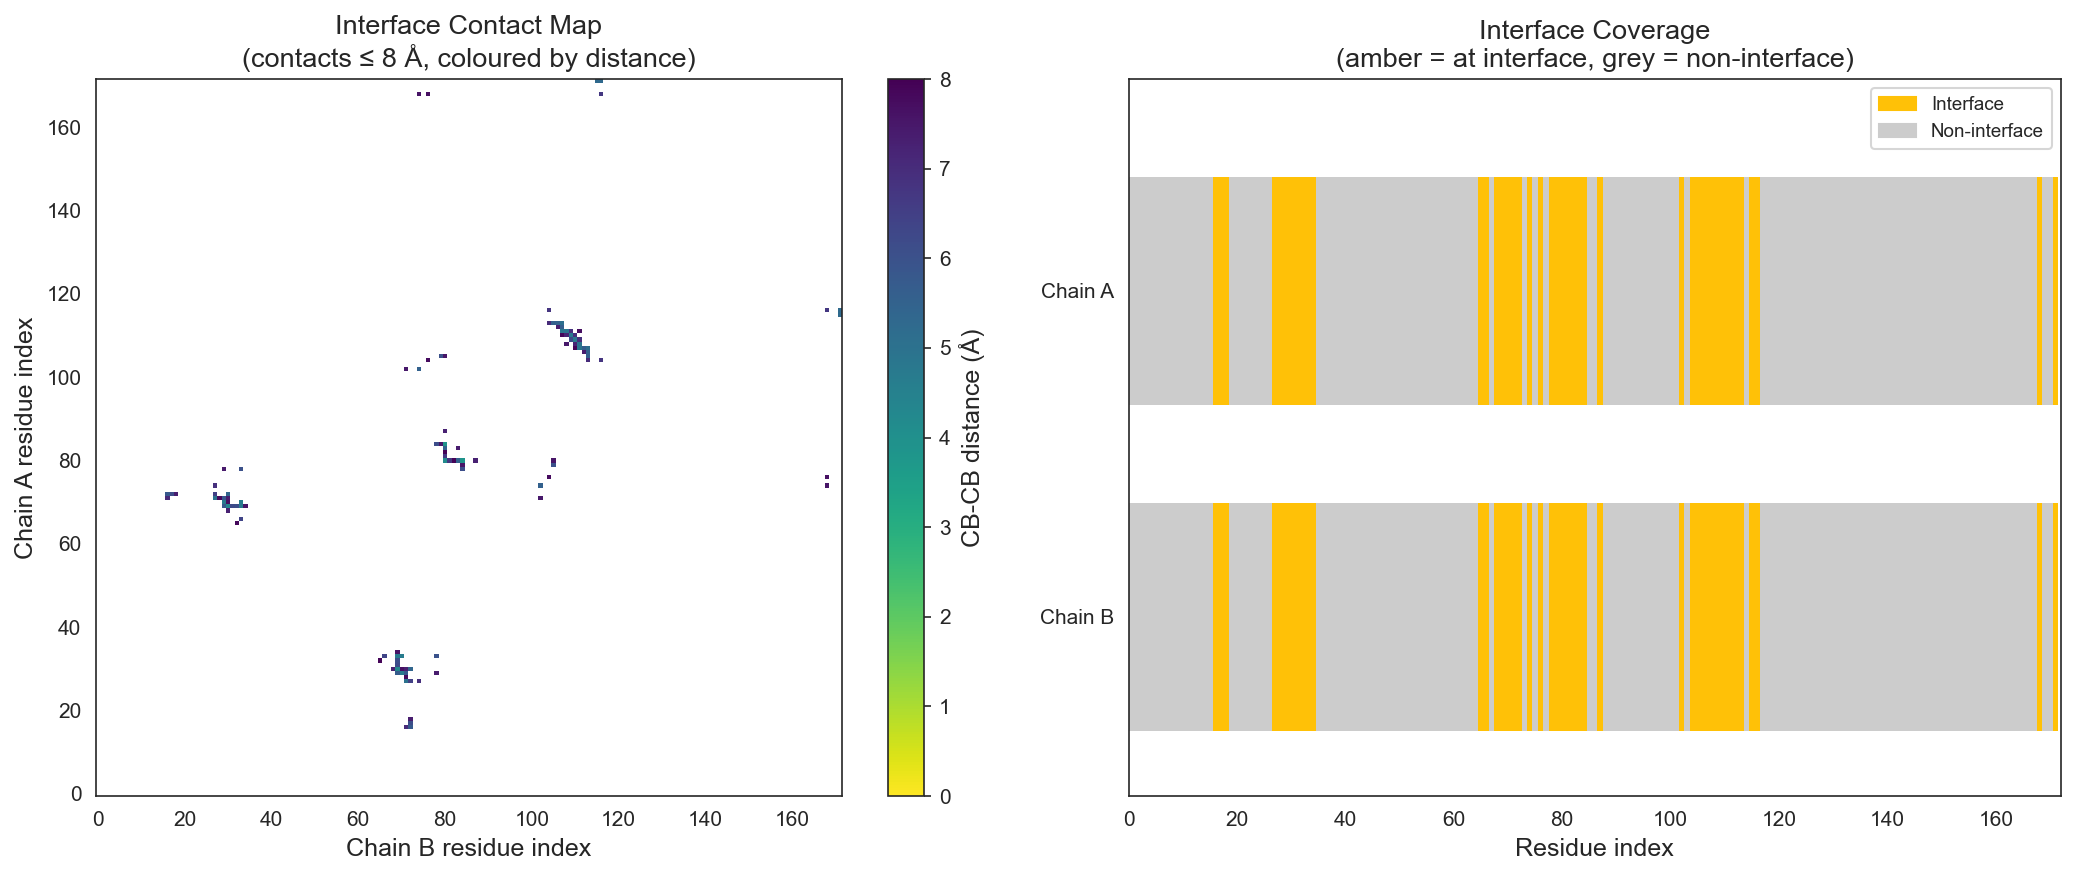

In [34]:
# ── Contact map ──────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Left: distance-coloured contact map
ax = axes[0]
contact_distances = np.where(contact_mask, dist_matrix, np.nan)
im = ax.imshow(contact_distances, aspect='auto', origin='lower',
               cmap='viridis_r', vmin=0, vmax=DIST_CUTOFF)
plt.colorbar(im, ax=ax, label='CB-CB distance (Å)')
ax.set_xlabel(f'Chain B residue index')
ax.set_ylabel(f'Chain A residue index')
ax.set_title('Interface Contact Map\n(contacts ≤ 8 Å, coloured by distance)')

# Right: interface coverage bars
ax2 = axes[1]
resids_A_arr = np.array(ch_resids[cA_id])
resids_B_arr = np.array(ch_resids[cB_id])

# Chain A bar
bar_height = 0.35
for i, is_if in enumerate(interface_A):
    colour = COLOUR_IF if is_if else '#CCCCCC'
    ax2.bar(i, bar_height, bottom=0.6, color=colour, width=1.0, linewidth=0)
# Chain B bar
for i, is_if in enumerate(interface_B):
    colour = COLOUR_IF if is_if else '#CCCCCC'
    ax2.bar(i, bar_height, bottom=0.1, color=colour, width=1.0, linewidth=0)

ax2.set_xlim(0, max(nA, nB))
ax2.set_ylim(0, 1.1)
ax2.set_yticks([0.275, 0.775])
ax2.set_yticklabels(['Chain B', 'Chain A'])
ax2.set_xlabel('Residue index')
ax2.set_title('Interface Coverage\n(amber = at interface, grey = non-interface)')
patch_if  = mpatches.Patch(color=COLOUR_IF, label='Interface')
patch_ni  = mpatches.Patch(color='#CCCCCC', label='Non-interface')
ax2.legend(handles=[patch_if, patch_ni], loc='upper right', fontsize=9)

plt.tight_layout()
plt.show()

---
## Section 3 — PAE Matrix Decomposition

**What is the PAE matrix?**
The Predicted Aligned Error (PAE) matrix is an N×N grid where N = total number of residues in both chains combined. Entry `[i, j]` = AlphaFold's estimate of how wrong the position of residue `i` would be, *if* we fixed residue `j` and rotated/translated everything else to align it.

- **Low PAE (blue)** → AlphaFold is confident about the relative position
- **High PAE (red)** → AlphaFold is uncertain

For a homodimer, the matrix has four quadrants:
- **Top-left (AA)**: confidence within chain A
- **Bottom-right (BB)**: confidence within chain B
- **Top-right (AB)** and **bottom-left (BA)**: confidence *between* chains — this is what all inter-chain scores use

Each score uses a different subset of the inter-chain region. The panel below shows which cells each score uses.

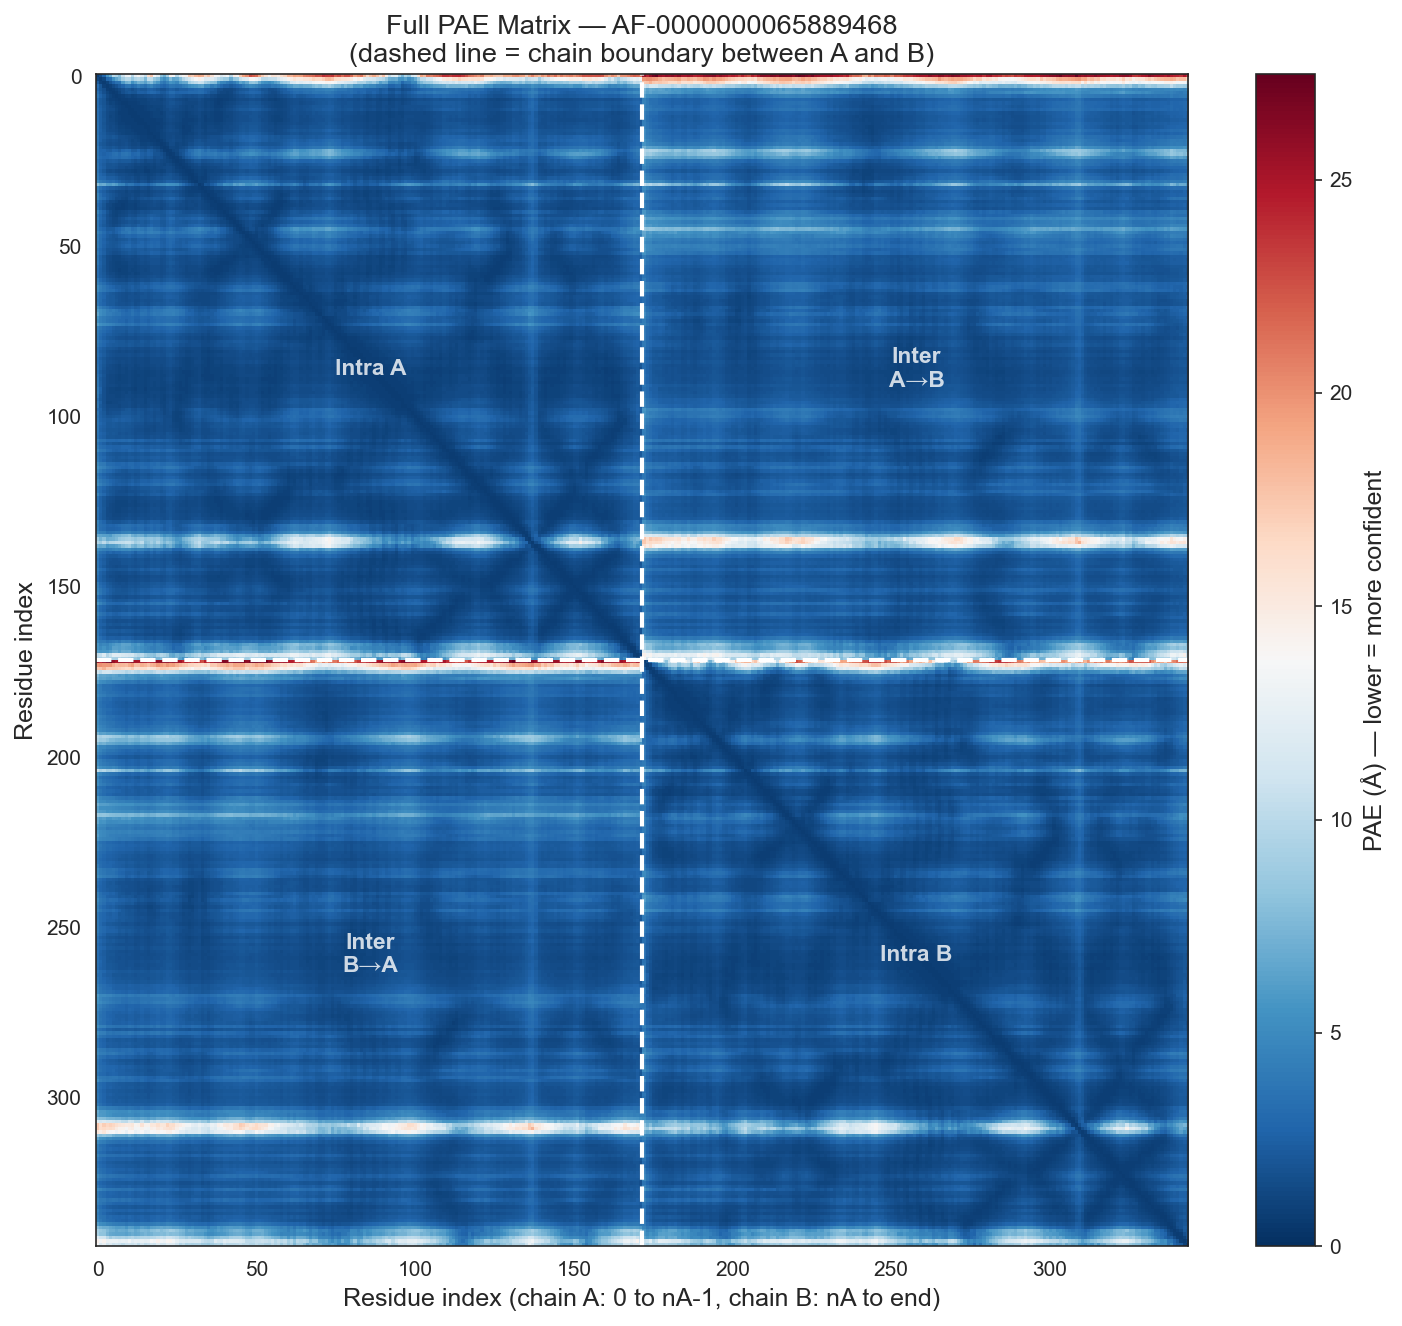

In [35]:
# ── Full PAE heatmap ─────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 9))

# Diverging palette: 0=dark-blue, 15=white, 31.75=dark-red (RdBu_r inverted)
cmap = plt.cm.RdBu_r
im = ax.imshow(pae_matrix, aspect='auto', origin='upper',
               cmap=cmap, vmin=0, vmax=pae_max)
plt.colorbar(im, ax=ax, label='PAE (Å) — lower = more confident')

# Chain boundary lines
ax.axhline(nA - 0.5, color='white', linewidth=2, linestyle='--')
ax.axvline(nA - 0.5, color='white', linewidth=2, linestyle='--')

# Quadrant labels
ax.text(nA/2, nA/2, 'Intra A', ha='center', va='center',
        color='white', fontsize=11, fontweight='bold', alpha=0.8)
ax.text(nA + nB/2, nA/2, 'Inter\nA→B', ha='center', va='center',
        color='white', fontsize=11, fontweight='bold', alpha=0.8)
ax.text(nA/2, nA + nB/2, 'Inter\nB→A', ha='center', va='center',
        color='white', fontsize=11, fontweight='bold', alpha=0.8)
ax.text(nA + nB/2, nA + nB/2, 'Intra B', ha='center', va='center',
        color='white', fontsize=11, fontweight='bold', alpha=0.8)

ax.set_xlabel('Residue index (chain A: 0 to nA-1, chain B: nA to end)')
ax.set_ylabel('Residue index')
ax.set_title(f'Full PAE Matrix — {ACCESSION_ID}\n'
             f'(dashed line = chain boundary between A and B)')
plt.tight_layout()
plt.show()

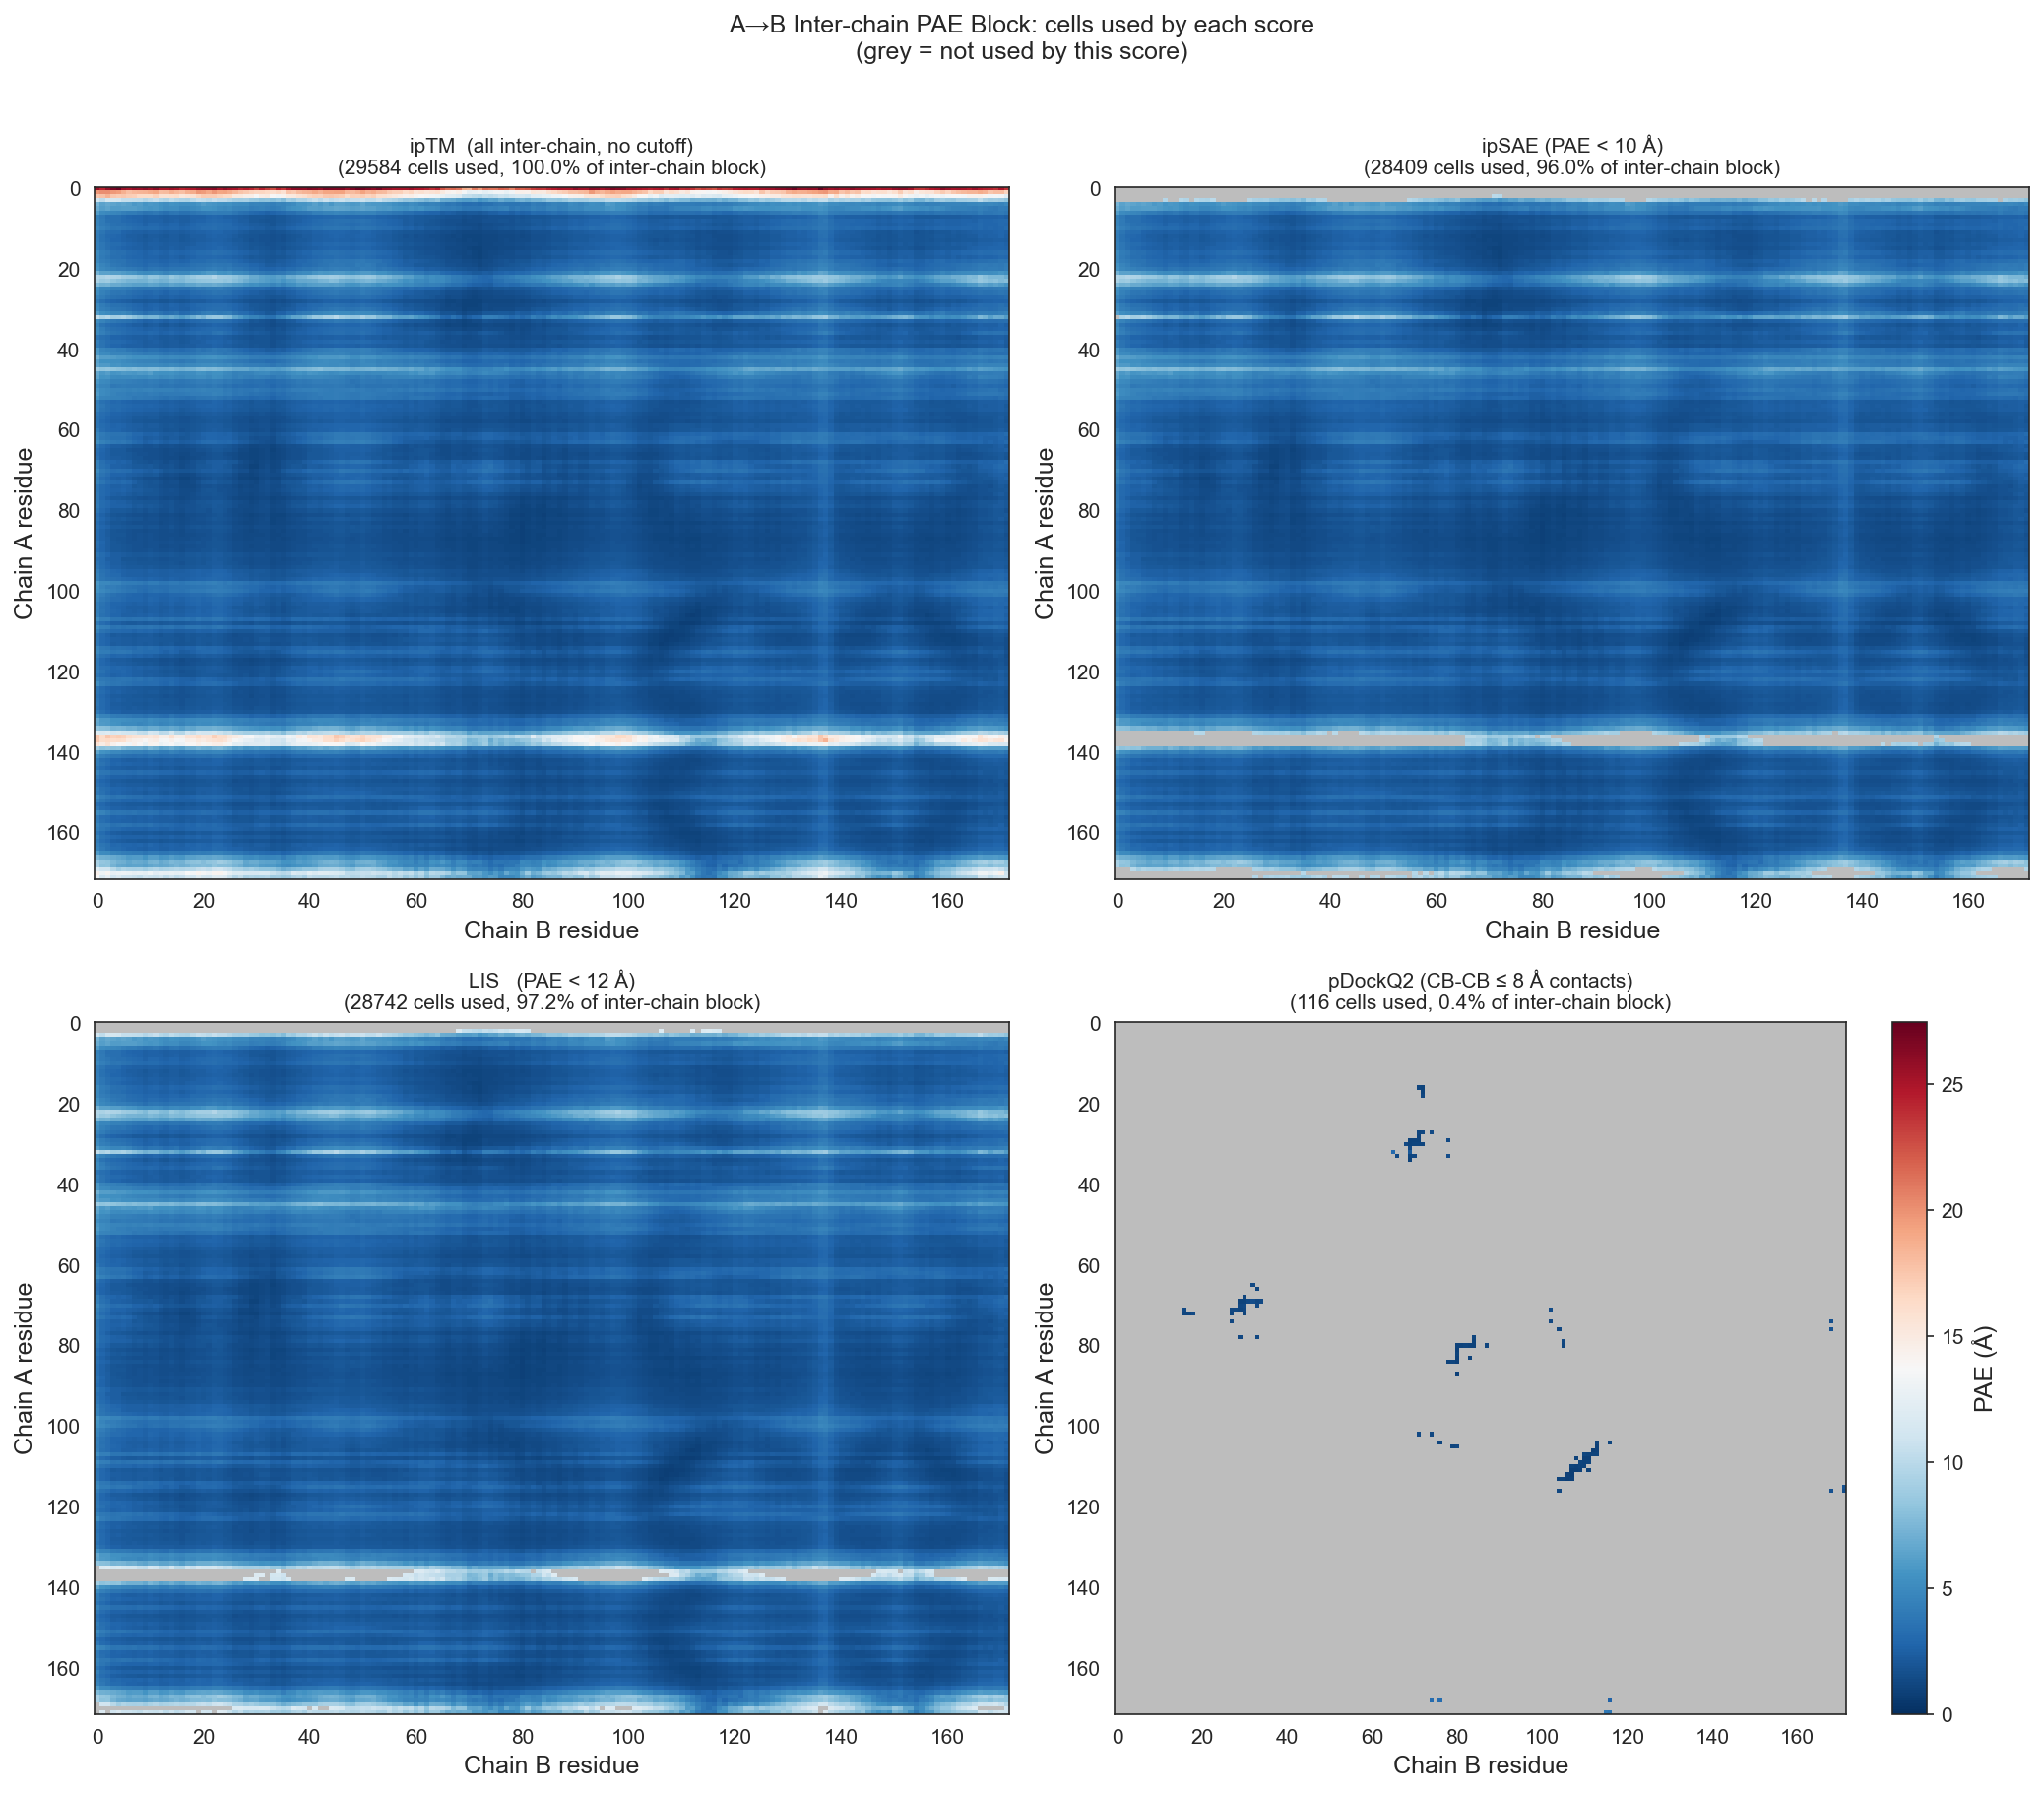

Summary of cells used by each score:
  ipTM  (all inter-chain, no cut  :  29584 cells (100.0%)
  ipSAE (PAE < 10 Å)              :  28409 cells (96.0%)
  LIS   (PAE < 12 Å)              :  28742 cells (97.2%)
  pDockQ2 (CB-CB ≤ 8 Å contacts)  :    116 cells (0.4%)


In [36]:
# ── PAE quadrant panels: which cells each score uses ─────────────────────────
# Show the A->B inter-chain block with different masks

# Build masks on pae_AB
mask_iptm   = np.ones((nA, nB), dtype=bool)                     # all cells
mask_ipsae  = pae_AB < PAE_CUTOFF                                # PAE < 10
mask_lis    = pae_AB < LIS_CUTOFF                                # PAE < 12
mask_pdockq2 = contact_mask.copy()                               # CB-CB ≤ 8 Å

titles = ['ipTM  (all inter-chain, no cutoff)',
          f'ipSAE (PAE < {PAE_CUTOFF:.0f} Å)',
          f'LIS   (PAE < {LIS_CUTOFF:.0f} Å)',
          f'pDockQ2 (CB-CB ≤ {DIST_CUTOFF:.0f} Å contacts)']
masks = [mask_iptm, mask_ipsae, mask_lis, mask_pdockq2]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.ravel()

for idx, (mask, title) in enumerate(zip(masks, titles)):
    ax = axes[idx]
    # Grey out non-contributing cells
    display_pae = pae_AB.copy().astype(float)
    display_pae[~mask] = np.nan
    grey_bg = np.ones((nA, nB)) * 35  # out-of-range sentinel

    im_bg = ax.imshow(grey_bg, aspect='auto', origin='upper',
                      cmap='Greys', vmin=0, vmax=40, alpha=0.3)
    im = ax.imshow(display_pae, aspect='auto', origin='upper',
                   cmap=plt.cm.RdBu_r, vmin=0, vmax=pae_max)
    n_cells = int(mask.sum())
    frac = 100 * n_cells / (nA * nB)
    ax.set_title(f'{title}\n({n_cells} cells used, {frac:.1f}% of inter-chain block)',
                 fontsize=10)
    ax.set_xlabel('Chain B residue')
    ax.set_ylabel('Chain A residue')

plt.colorbar(im, ax=axes[-1], label='PAE (Å)')
fig.suptitle('A→B Inter-chain PAE Block: cells used by each score\n'
             '(grey = not used by this score)', fontsize=12, y=1.01)
plt.tight_layout()
plt.show()

print(f'Summary of cells used by each score:')
for mask, title in zip(masks, titles):
    print(f'  {title[:30]:32s}: {int(mask.sum()):6d} cells ({100*mask.sum()/(nA*nB):.1f}%)')

---
## Section 4 — Score Computation and Decomposition

**What we do here:** Compute all five confidence scores from scratch, showing every intermediate value.

All PAE-based scores use a **TM-score function**: `ptm(x, d0) = 1 / (1 + (x/d0)²)`. This converts a PAE value `x` into a score from 0 (bad) to 1 (perfect). The parameter `d0` controls how steeply the score falls off with increasing PAE.

The `d0` is computed from `L` (number of relevant residues): `d0(L) = max(1.0, 1.24 × (L−15)^(1/3) − 1.8)`.

Scores that use *more* residues for normalisation have a *larger* `d0`, making them more lenient. This is why the three ipSAE variants (d0res, d0chn, d0dom) can give very different values.

In [37]:
# ── Core scoring functions ────────────────────────────────────────────────────

def d0_func(L):
    """Length-dependent normalisation factor for TM-score."""
    if L <= 27:
        return 1.0
    return max(1.0, 1.24 * (L - 15) ** (1.0 / 3.0) - 1.8)


def ptm_func(pae_vals, d0):
    """TM-score function: 1/(1+(x/d0)^2). Works on scalars or arrays."""
    return 1.0 / (1.0 + (pae_vals / d0) ** 2)


# ── pDockQ ────────────────────────────────────────────────────────────────────
def compute_pdockq(dist_mat, plddt_a, plddt_b, cutoff=8.0):
    """Bryant et al. (2022). Uses contact count and interface pLDDT."""
    cmask = dist_mat <= cutoff
    n_c = int(cmask.sum())
    if n_c == 0:
        return dict(score=0.018, n_contacts=0, mean_plddt=0.0, x=0.0,
                    if_A=np.zeros(len(plddt_a), bool),
                    if_B=np.zeros(len(plddt_b), bool))
    if_A = np.any(cmask, axis=1)
    if_B = np.any(cmask, axis=0)
    mean_plddt = float(np.concatenate([plddt_a[if_A], plddt_b[if_B]]).mean())
    x = mean_plddt * np.log10(n_c)
    score = 0.724 / (1.0 + np.exp(-0.052 * (x - 152.611))) + 0.018
    return dict(score=float(score), n_contacts=n_c, mean_plddt=mean_plddt, x=float(x),
                if_A=if_A, if_B=if_B)


# ── pDockQ2 ───────────────────────────────────────────────────────────────────
def compute_pdockq2(dist_mat, pae_ab, plddt_a, plddt_b, cutoff=8.0, fixed_d0=10.0):
    """Zhu et al. (2023). Combines contact PAE with interface pLDDT."""
    cmask = dist_mat <= cutoff
    n_c = int(cmask.sum())
    if n_c == 0:
        return dict(score=0.005, n_contacts=0, mean_ptm=0.0, mean_plddt=0.0, x=0.0,
                    if_A=np.zeros(len(plddt_a), bool),
                    if_B=np.zeros(len(plddt_b), bool))
    if_A = np.any(cmask, axis=1)
    if_B = np.any(cmask, axis=0)
    contact_pae = pae_ab[cmask]
    mean_ptm    = float(ptm_func(contact_pae, fixed_d0).mean())
    mean_plddt  = float(np.concatenate([plddt_a[if_A], plddt_b[if_B]]).mean())
    x     = mean_plddt * mean_ptm
    score = 1.31 / (1.0 + np.exp(-0.075 * (x - 84.733))) + 0.005
    return dict(score=float(score), n_contacts=n_c, mean_ptm=mean_ptm,
                mean_plddt=mean_plddt, x=float(x), if_A=if_A, if_B=if_B)


# ── LIS ───────────────────────────────────────────────────────────────────────
def compute_lis(pae_ab, pae_ba, lis_cut=12.0):
    """Kim et al. (2024). Mean linear transform of inter-chain PAE < cutoff."""
    def _lis_one(block):
        v = block[block < lis_cut]
        if len(v) == 0:
            return 0.0, 0
        return float(((lis_cut - v) / lis_cut).mean()), len(v)
    lis_ab, n_ab = _lis_one(pae_ab)
    lis_ba, n_ba = _lis_one(pae_ba)
    return dict(score=(lis_ab + lis_ba) / 2.0,
                lis_AB=lis_ab, lis_BA=lis_ba,
                n_valid_AB=n_ab, n_valid_BA=n_ba)


# ── ipTM (ipTM_d0chn) ─────────────────────────────────────────────────────────
def compute_iptm(pae_ab, pae_ba, nA, nB):
    """Max per-residue mean ptm, d0 based on full chain pair length."""
    d0_chn = d0_func(nA + nB)
    per_res_ab = ptm_func(pae_ab, d0_chn).mean(axis=1)  # (nA,)
    per_res_ba = ptm_func(pae_ba, d0_chn).mean(axis=1)  # (nB,)
    iptm_ab = float(per_res_ab.max())
    iptm_ba = float(per_res_ba.max())
    return dict(score=max(iptm_ab, iptm_ba),
                iptm_AB=iptm_ab, iptm_BA=iptm_ba,
                per_res_AB=per_res_ab, per_res_BA=per_res_ba,
                d0_chn=d0_chn,
                best_res_AB=int(per_res_ab.argmax()),
                best_res_BA=int(per_res_ba.argmax()))


# ── ipSAE (three d0 variants) ─────────────────────────────────────────────────
def compute_ipsae(pae_ab, pae_ba, nA, nB, pae_cut=10.0):
    """Dunbrack Lab (2025). Three d0 variants; returns all."""
    d0_chn = d0_func(nA + nB)
    # d0_dom: residues in either chain with any inter-chain PAE < cutoff
    n_dom = (int(np.any(pae_ab < pae_cut, axis=1).sum()) +
             int(np.any(pae_ab < pae_cut, axis=0).sum()))
    d0_dom = d0_func(n_dom)

    def _per_res(pae_cross, n_src):
        r_d0res = np.zeros(n_src)
        r_d0chn = np.zeros(n_src)
        r_d0dom = np.zeros(n_src)
        for i in range(n_src):
            valid = pae_cross[i] < pae_cut
            n0 = int(valid.sum())
            if n0 == 0:
                continue
            vp = pae_cross[i, valid]
            r_d0res[i] = float(ptm_func(vp, d0_func(n0)).mean())
            r_d0chn[i] = float(ptm_func(vp, d0_chn).mean())
            r_d0dom[i] = float(ptm_func(vp, d0_dom).mean())
        return r_d0res, r_d0chn, r_d0dom

    ab = _per_res(pae_ab, nA)
    ba = _per_res(pae_ba, nB)

    return dict(
        ipsae_d0res=max(float(ab[0].max()), float(ba[0].max())),
        ipsae_d0chn=max(float(ab[1].max()), float(ba[1].max())),
        ipsae_d0dom=max(float(ab[2].max()), float(ba[2].max())),
        per_res_AB_d0res=ab[0], per_res_AB_d0chn=ab[1], per_res_AB_d0dom=ab[2],
        per_res_BA_d0res=ba[0], per_res_BA_d0chn=ba[1], per_res_BA_d0dom=ba[2],
        d0_chn=d0_chn, d0_dom=d0_dom, n_dom=n_dom,
    )

print('Score functions defined.')

Score functions defined.


In [38]:
# ── Run all scores ─────────────────────────────────────────────────────────────
res_pdockq  = compute_pdockq(dist_matrix, plddt_A, plddt_B)
res_pdockq2 = compute_pdockq2(dist_matrix, pae_AB, plddt_A, plddt_B)
res_lis     = compute_lis(pae_AB, pae_BA)
res_iptm    = compute_iptm(pae_AB, pae_BA, nA, nB)
res_ipsae   = compute_ipsae(pae_AB, pae_BA, nA, nB, pae_cut=PAE_CUTOFF)

# Collect final scores
scores = {
    'ipSAE_d0res': res_ipsae['ipsae_d0res'],
    'ipSAE_d0chn': res_ipsae['ipsae_d0chn'],
    'ipSAE_d0dom': res_ipsae['ipsae_d0dom'],
    'ipTM':        res_iptm['score'],
    'pDockQ':      res_pdockq['score'],
    'pDockQ2':     res_pdockq2['score'],
    'LIS':         res_lis['score'],
}

print('\n── Score Results ──────────────────────────────')
for name, val in scores.items():
    print(f'  {name:18s}: {val:.4f}')

print('\n── Intermediate Values ────────────────────────')
print(f'  pDockQ   n_contacts : {res_pdockq["n_contacts"]}')
print(f'  pDockQ   mean_pLDDT : {res_pdockq["mean_plddt"]:.2f}')
print(f'  pDockQ   x          : {res_pdockq["x"]:.4f}')
print(f'  pDockQ2  mean_ptm   : {res_pdockq2["mean_ptm"]:.4f}')
print(f'  pDockQ2  mean_pLDDT : {res_pdockq2["mean_plddt"]:.2f}')
print(f'  pDockQ2  x          : {res_pdockq2["x"]:.4f}')
print(f'  LIS      n_valid_AB : {res_lis["n_valid_AB"]}')
print(f'  LIS      n_valid_BA : {res_lis["n_valid_BA"]}')
print(f'  ipTM     d0_chn     : {res_iptm["d0_chn"]:.4f}')
print(f'  ipTM     best_res_AB: {res_iptm["best_res_AB"]}')
print(f'  ipSAE    d0_chn     : {res_ipsae["d0_chn"]:.4f}')
print(f'  ipSAE    d0_dom     : {res_ipsae["d0_dom"]:.4f}  (n_dom={res_ipsae["n_dom"]})')


── Score Results ──────────────────────────────
  ipSAE_d0res       : 0.9143
  ipSAE_d0chn       : 0.9529
  ipSAE_d0dom       : 0.9527
  ipTM              : 0.9529
  pDockQ            : 0.6913
  pDockQ2           : 0.9269
  LIS               : 0.7564

── Intermediate Values ────────────────────────
  pDockQ   n_contacts : 116
  pDockQ   mean_pLDDT : 98.01
  pDockQ   x          : 202.3361
  pDockQ2  mean_ptm   : 0.9823
  pDockQ2  mean_pLDDT : 98.01
  pDockQ2  x          : 96.2702
  LIS      n_valid_AB : 28742
  LIS      n_valid_BA : 28754
  ipTM     d0_chn     : 6.7603
  ipTM     best_res_AB: 87
  ipSAE    d0_chn     : 6.7603
  ipSAE    d0_dom     : 6.7429  (n_dom=342)


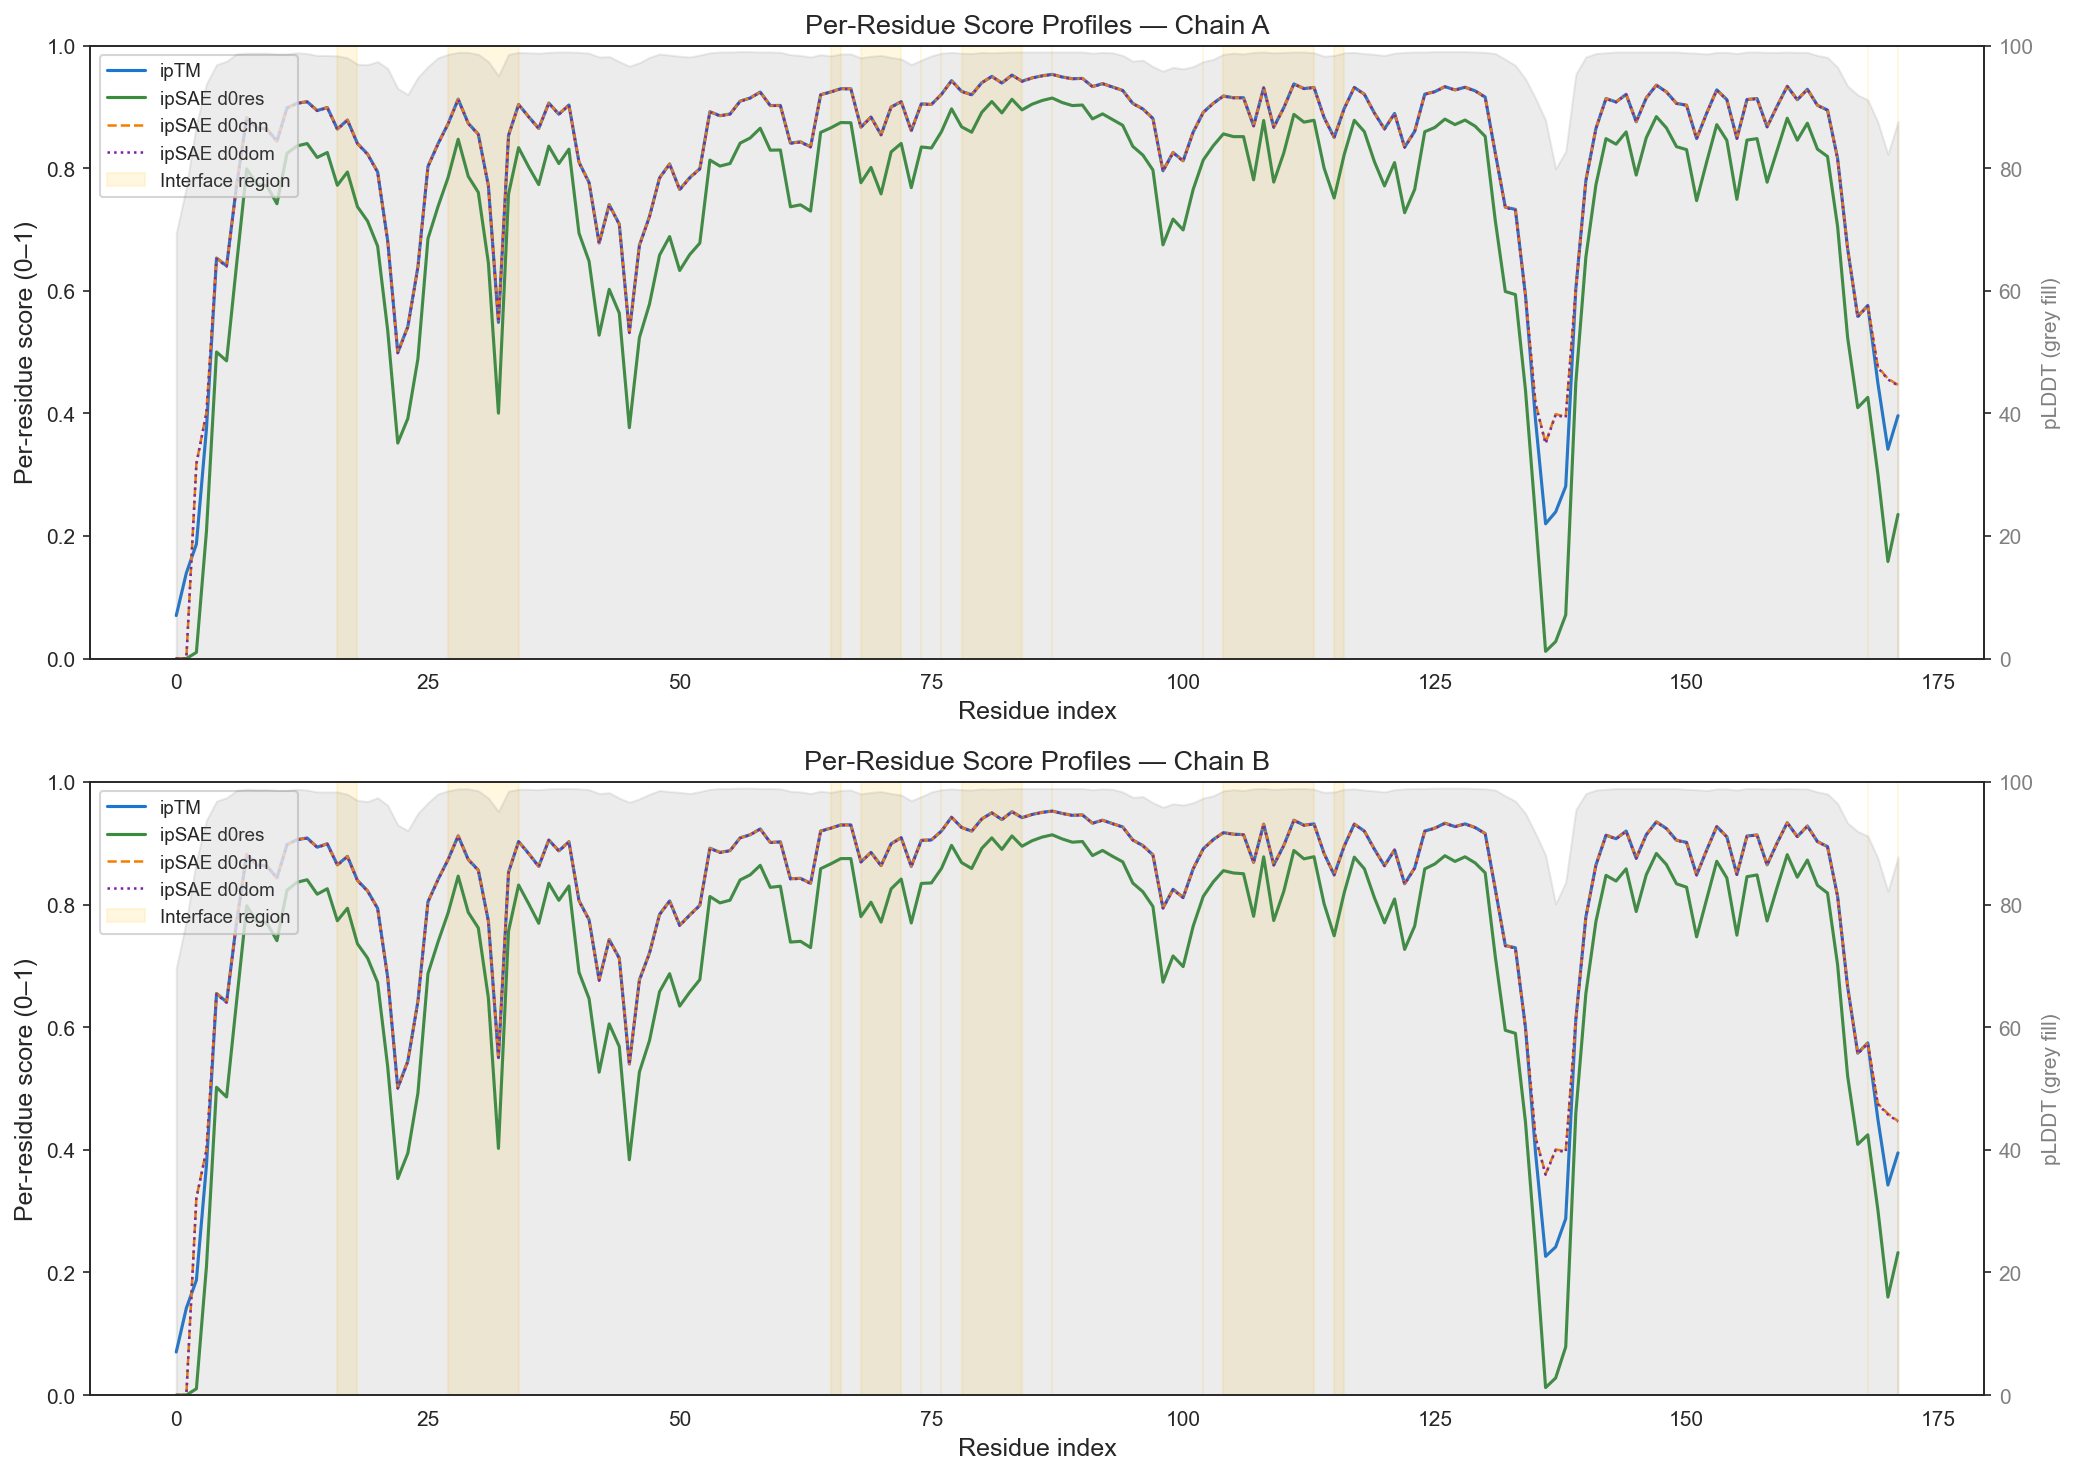

In [39]:
# ── Per-residue score profiles ─────────────────────────────────────────────────
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=False)

for ax_idx, (chain_label, chain_id, per_res_iptm, per_res_d0res, per_res_d0chn,
             per_res_d0dom, plddt_chain, resids_arr) in enumerate([
    ('Chain A', cA_id,
     res_iptm['per_res_AB'], res_ipsae['per_res_AB_d0res'],
     res_ipsae['per_res_AB_d0chn'], res_ipsae['per_res_AB_d0dom'],
     plddt_A, np.arange(nA)),
    ('Chain B', cB_id,
     res_iptm['per_res_BA'], res_ipsae['per_res_BA_d0res'],
     res_ipsae['per_res_BA_d0chn'], res_ipsae['per_res_BA_d0dom'],
     plddt_B, np.arange(nB)),
]):
    ax = axes[ax_idx]
    x = resids_arr

    ax.plot(x, per_res_iptm,    label='ipTM',         color='#1976D2', linewidth=1.5)
    ax.plot(x, per_res_d0res,   label='ipSAE d0res',  color='#388E3C', linewidth=1.5)
    ax.plot(x, per_res_d0chn,   label='ipSAE d0chn',  color='#F57C00', linewidth=1.2, linestyle='--')
    ax.plot(x, per_res_d0dom,   label='ipSAE d0dom',  color='#7B1FA2', linewidth=1.2, linestyle=':')

    # Secondary axis: pLDDT
    ax2 = ax.twinx()
    ax2.fill_between(x, plddt_chain, alpha=0.15, color='grey', label='pLDDT')
    ax2.set_ylabel('pLDDT (grey fill)', color='grey', fontsize=10)
    ax2.set_ylim(0, 100)
    ax2.tick_params(axis='y', labelcolor='grey')

    # Mark interface residues
    if_mask = interface_A if ax_idx == 0 else interface_B
    ax.fill_between(x, 0, 1, where=if_mask,
                    alpha=0.12, color=COLOUR_IF, label='Interface region')

    ax.set_ylim(0, 1)
    ax.set_xlabel('Residue index')
    ax.set_ylabel('Per-residue score (0–1)')
    ax.set_title(f'Per-Residue Score Profiles — {chain_label}')
    ax.legend(loc='upper left', fontsize=9)

plt.tight_layout()
plt.show()

---
## Section 5 — Per-Residue pLDDT at the Interface

**What is pLDDT?**
pLDDT (predicted Local Distance Difference Test) is AlphaFold's confidence score for each individual residue, ranging from 0 to 100. A score above 90 means AlphaFold is very confident about that residue's position within its local neighbourhood; below 50 means the residue is likely disordered.

**Why look at interface pLDDT separately?**
pDockQ scores depend on the pLDDT of interface residues. If the interface contains many low-pLDDT residues, pDockQ will be dragged down even if the structural contacts look physically reasonable. Comparing interface vs. non-interface pLDDT distributions helps us understand whether a low pDockQ reflects a *globally* uncertain protein or specifically uncertain *interface* residues.

**AlphaFold colour scheme:** dark blue (>90) → light blue (70–90) → yellow (50–70) → orange (<50).

Interface pLDDT   mean=98.0, median=98.6
Non-interface     mean=97.0, median=98.6
Low-pLDDT (<70) interface residues: 0 / 86 (0.0%)


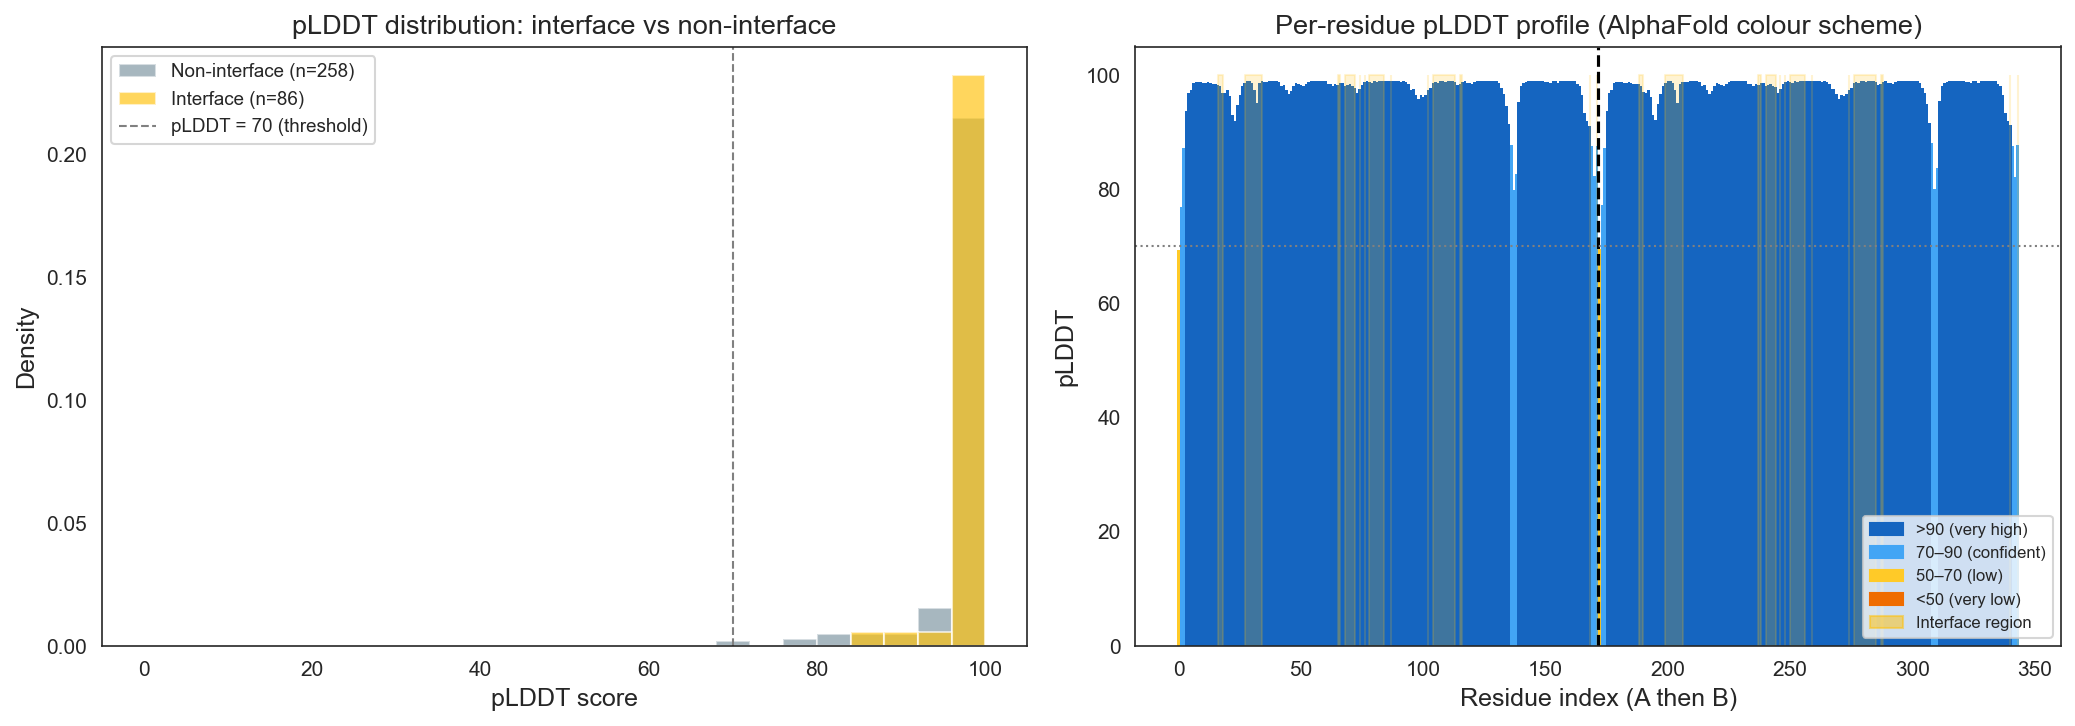

In [40]:
# ── pLDDT distribution: interface vs non-interface ────────────────────────────
all_plddt_A = plddt_A
all_plddt_B = plddt_B

if_plddt = np.concatenate([plddt_A[interface_A], plddt_B[interface_B]])
ni_plddt = np.concatenate([plddt_A[~interface_A], plddt_B[~interface_B]])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Overlaid histograms
ax = axes[0]
bins = np.linspace(0, 100, 26)
ax.hist(ni_plddt, bins=bins, alpha=0.55, color='#607D8B',
        label=f'Non-interface (n={len(ni_plddt)})', density=True)
ax.hist(if_plddt, bins=bins, alpha=0.65, color=COLOUR_IF,
        label=f'Interface (n={len(if_plddt)})', density=True)
ax.axvline(70, color='grey', linestyle='--', linewidth=1, label='pLDDT = 70 (threshold)')
ax.set_xlabel('pLDDT score')
ax.set_ylabel('Density')
ax.set_title('pLDDT distribution: interface vs non-interface')
ax.legend(fontsize=9)

print(f'Interface pLDDT   mean={if_plddt.mean():.1f}, median={np.median(if_plddt):.1f}')
print(f'Non-interface     mean={ni_plddt.mean():.1f}, median={np.median(ni_plddt):.1f}')
n_low_if = int((if_plddt < 70).sum())
print(f'Low-pLDDT (<70) interface residues: {n_low_if} / {len(if_plddt)} '
      f'({100*n_low_if/max(len(if_plddt),1):.1f}%)')

# Right: full pLDDT profile with interface bands
ax2 = axes[1]
full_plddt = np.concatenate([plddt_A, plddt_B])
full_x     = np.arange(len(full_plddt))
full_if    = np.concatenate([interface_A, interface_B])

# AlphaFold colour scheme
def plddt_colour(v):
    if v > 90: return '#1565C0'
    if v > 70: return '#42A5F5'
    if v > 50: return '#FFCA28'
    return '#EF6C00'

colours = [plddt_colour(v) for v in full_plddt]
ax2.bar(full_x, full_plddt, color=colours, width=1.0, linewidth=0)
# Overlay interface regions
ax2.fill_between(full_x, 0, 100, where=full_if,
                 alpha=0.18, color=COLOUR_IF, label='Interface residues')
ax2.axvline(nA - 0.5, color='black', linewidth=1.5, linestyle='--', label='Chain A/B boundary')
ax2.axhline(70, color='grey', linestyle=':', linewidth=1)
ax2.set_xlabel('Residue index (A then B)')
ax2.set_ylabel('pLDDT')
ax2.set_title('Per-residue pLDDT profile (AlphaFold colour scheme)')

from matplotlib.patches import Patch
legend_patches = [
    Patch(color='#1565C0', label='>90 (very high)'),
    Patch(color='#42A5F5', label='70–90 (confident)'),
    Patch(color='#FFCA28', label='50–70 (low)'),
    Patch(color='#EF6C00', label='<50 (very low)'),
    Patch(color=COLOUR_IF, alpha=0.5, label='Interface region'),
]
ax2.legend(handles=legend_patches, fontsize=8, loc='lower right')

plt.tight_layout()
plt.show()

---
## Section 6 — 3D Structure Visualisation (MolViewSpec)

**What is MolViewSpec?**
MolViewSpec is a format for describing 3D molecular visualisations. We use it to colour the protein structure by different diagnostic criteria and then view it in **Mol***, the same interactive 3D viewer used by the PDBe and RCSB databases.

We generate four views:
1. **Overview** — chains coloured teal (A) and coral (B), interface in amber
2. **pLDDT mapping** — residues coloured by confidence (AlphaFold colour scheme)
3. **Interface diagnostic** — interface residues coloured by per-residue ipSAE score
4. **Disagreement** — residues where PAE-based (ipSAE) and contact-based (pDockQ) signals diverge

Each view generates a link to open in the Mol* web viewer.

In [ ]:
# ── MolViewSpec 3D views ───────────────────────────────────────────────────────
try:
    import molviewspec as mvs
    MVS_AVAILABLE = True
    print(f'molviewspec version: {mvs.__version__}')
except Exception as e:
    MVS_AVAILABLE = False
    print(f'molviewspec not available: {e}')


def show_mol_view(state, label, width=950, height=600):
    """Render a MolViewSpec State inline via a base64 data-URI iframe (works in PyCharm)."""
    html = state.molstar_html()
    encoded = base64.b64encode(html.encode()).decode()
    display(HTML(f'<div style="margin:10px 0 4px; font-weight:bold;">{label}</div>'))
    display(IFrame(src=f'data:text/html;base64,{encoded}', width=width, height=height))


if MVS_AVAILABLE:
    # Determine the bcifUrl or fall back to cifUrl
    struct_url = meta.get('bcifUrl', meta.get('cifUrl', cif_url))
    struct_fmt = 'bcif' if 'bcifUrl' in meta else 'mmcif'

    # ── View 1: Chain overview ─────────────────────────────────────────────────
    try:
        builder = mvs.create_builder()
        structure = (
            builder
            .download(url=struct_url)
            .parse(format=struct_fmt)
            .model_structure()
        )
        # Chain A — teal
        (structure
         .component(selector=mvs.ComponentExpression(label_asym_id='A'))
         .representation(type='cartoon')
         .color(color='#009688'))
        # Chain B — coral
        (structure
         .component(selector=mvs.ComponentExpression(label_asym_id='B'))
         .representation(type='cartoon')
         .color(color='#FF7043'))
        # Interface residues — amber (chain A)
        if_A_resids = [ch_resids[cA_id][i] for i in np.where(interface_A)[0]]
        for r in if_A_resids:
            (structure
             .component(selector=mvs.ComponentExpression(label_asym_id='A',
                                                          beg_label_seq_id=r, end_label_seq_id=r))
             .representation(type='ball_and_stick')
             .color(color='#FFC107'))
        show_mol_view(builder.get_state(), 'View 1: Chain Overview (teal=A, coral=B, amber=interface)')
    except Exception as e:
        print(f'View 1 failed: {e}')

    # ── View 2: pLDDT mapping ──────────────────────────────────────────────────
    try:
        builder2 = mvs.create_builder()
        structure2 = (
            builder2
            .download(url=struct_url)
            .parse(format=struct_fmt)
            .model_structure()
        )
        plddt_colours = [
            (90, 100, '#1565C0'),   # dark blue
            (70,  90, '#42A5F5'),   # light blue
            (50,  70, '#FFCA28'),   # yellow
            ( 0,  50, '#EF6C00'),   # orange
        ]
        for chain_label in ['A', 'B']:
            plddt_arr = plddt_A if chain_label == 'A' else plddt_B
            resids_arr_ = ch_resids[cA_id if chain_label == 'A' else cB_id]
            for lo, hi, colour in plddt_colours:
                idx_range = np.where((plddt_arr >= lo) & (plddt_arr < hi))[0]
                for i in idx_range:
                    r = resids_arr_[i]
                    (structure2
                     .component(selector=mvs.ComponentExpression(
                         label_asym_id=chain_label,
                         beg_label_seq_id=r, end_label_seq_id=r))
                     .representation(type='cartoon')
                     .color(color=colour))
        show_mol_view(builder2.get_state(), 'View 2: pLDDT Mapping (dark blue>90, light blue 70–90, yellow 50–70, orange<50)')
    except Exception as e:
        print(f'View 2 failed: {e}')

    # ── View 3: Interface coloured by ipSAE d0res score ────────────────────────
    try:
        import matplotlib.cm as cm
        cmap_rg = cm.get_cmap('RdYlGn')

        builder3 = mvs.create_builder()
        structure3 = (
            builder3
            .download(url=struct_url)
            .parse(format=struct_fmt)
            .model_structure()
        )
        (structure3.component().representation(type='cartoon').color(color='#BDBDBD'))

        for chain_label, if_mask, per_res_arr, resids_ch in [
            ('A', interface_A, res_ipsae['per_res_AB_d0res'], ch_resids[cA_id]),
            ('B', interface_B, res_ipsae['per_res_BA_d0res'], ch_resids[cB_id]),
        ]:
            for i in np.where(if_mask)[0]:
                score_val = float(per_res_arr[i])
                rgba = cmap_rg(score_val)
                hex_colour = '#{:02X}{:02X}{:02X}'.format(
                    int(rgba[0]*255), int(rgba[1]*255), int(rgba[2]*255))
                r = resids_ch[i]
                (structure3
                 .component(selector=mvs.ComponentExpression(
                     label_asym_id=chain_label,
                     beg_label_seq_id=r, end_label_seq_id=r))
                 .representation(type='ball_and_stick')
                 .color(color=hex_colour))
        show_mol_view(builder3.get_state(), 'View 3: Interface ipSAE d0res score (red=low, yellow=mid, green=high)')
    except Exception as e:
        print(f'View 3 failed: {e}')

    # ── View 4: PAE/contact disagreement regions ───────────────────────────────
    try:
        ipsae_thresh = 0.5
        pae_agree_A = (res_ipsae['per_res_AB_d0res'] > ipsae_thresh) & interface_A
        pae_only_A  = (res_ipsae['per_res_AB_d0res'] > ipsae_thresh) & ~interface_A
        cont_only_A = (res_ipsae['per_res_AB_d0res'] <= ipsae_thresh) & interface_A

        builder4 = mvs.create_builder()
        structure4 = (
            builder4
            .download(url=struct_url)
            .parse(format=struct_fmt)
            .model_structure()
        )
        (structure4.component().representation(type='cartoon').color(color='#EEEEEE'))

        colour_map_view4 = [
            (pae_agree_A, 'A', '#4CAF50', 'PAE+contact agree'),
            (pae_only_A,  'A', '#2196F3', 'PAE confident, no contact'),
            (cont_only_A, 'A', '#F44336', 'Contact, low PAE confidence'),
        ]
        for mask, chain_label, colour, _ in colour_map_view4:
            for i in np.where(mask)[0]:
                r = ch_resids[cA_id][i]
                (structure4
                 .component(selector=mvs.ComponentExpression(
                     label_asym_id=chain_label,
                     beg_label_seq_id=r, end_label_seq_id=r))
                 .representation(type='ball_and_stick')
                 .color(color=colour))
        show_mol_view(builder4.get_state(), 'View 4: Disagreement (green=PAE+contact, blue=PAE confident/no contact, red=contact/low PAE)')
    except Exception as e:
        print(f'View 4 failed: {e}')

else:
    print('Skipping 3D views — molviewspec not installed.')

---
## Section 7 — Diagnostic Summary

**What we do here:** Bring together all five scores into a single interpretable diagnostic.

**Traffic-light thresholds** (based on AFDB filtering criteria and literature):
- **Green (high confidence):** ipSAE_d0res ≥ 0.6, ipTM ≥ 0.6, pDockQ ≥ 0.23, pDockQ2 ≥ 0.15, LIS ≥ 0.3
- **Amber (moderate):** half of the above thresholds
- **Red (low confidence):** below amber

These thresholds are starting heuristics; see the references for more detail.

In [42]:
# ── Score summary table with traffic-light colouring ─────────────────────────
thresholds = {
    'ipSAE_d0res': (0.6,  0.3),
    'ipSAE_d0chn': (0.5,  0.25),
    'ipSAE_d0dom': (0.55, 0.28),
    'ipTM':        (0.6,  0.3),
    'pDockQ':      (0.23, 0.115),
    'pDockQ2':     (0.15, 0.075),
    'LIS':         (0.3,  0.15),
}

descriptions = {
    'ipSAE_d0res': 'Primary AFDB classifier. Inter-chain PAE, d0 from valid-pair count.',
    'ipSAE_d0chn': 'Conservative variant. Penalises small interfaces more.',
    'ipSAE_d0dom': 'Intermediate variant. d0 from domain-level residue count.',
    'ipTM':        'Global inter-chain confidence. All PAE cells used, no cutoff.',
    'pDockQ':      'Structural plausibility. Contact count x interface pLDDT. No PAE.',
    'pDockQ2':     'Contact PAE + interface pLDDT. Bridges pDockQ and ipSAE.',
    'LIS':         'Density of inter-chain PAE < 12. Quantity of interaction.',
}

def traffic_light(val, green_thresh, amber_thresh):
    if val >= green_thresh: return 'green', 'HIGH'
    if val >= amber_thresh: return 'amber', 'MODERATE'
    return 'red', 'LOW'

colour_hex = {'green': '#4CAF50', 'amber': '#FF9800', 'red': '#F44336'}

# Build HTML table
rows = ''
for name, val in scores.items():
    g_thresh, a_thresh = thresholds[name]
    tl_colour, tl_label = traffic_light(val, g_thresh, a_thresh)
    hex_c = colour_hex[tl_colour]
    desc  = descriptions[name]
    rows += (
        f'<tr>'
        f'<td style="font-weight:bold;padding:6px 12px;">{name}</td>'
        f'<td style="padding:6px 12px;text-align:center;font-size:1.15em;font-weight:bold;">'
        f'{val:.4f}</td>'
        f'<td style="padding:6px 12px;text-align:center;">'
        f'<span style="background:{hex_c};color:white;padding:3px 10px;border-radius:12px;'
        f'font-weight:bold;font-size:0.85em;">{tl_label}</span></td>'
        f'<td style="padding:6px 12px;font-size:0.88em;color:#555;">{desc}</td>'
        f'</tr>'
    )

html = (
    f'<h3>Confidence Score Summary — {ACCESSION_ID}</h3>'
    f'<table style="border-collapse:collapse;width:100%;font-family:sans-serif;">'
    f'<thead><tr style="background:#f5f5f5;">'
    f'<th style="padding:8px 12px;text-align:left;">Score</th>'
    f'<th style="padding:8px 12px;">Value</th>'
    f'<th style="padding:8px 12px;">Confidence</th>'
    f'<th style="padding:8px 12px;text-align:left;">What it measures</th>'
    f'</tr></thead><tbody>{rows}</tbody></table>'
)
display(HTML(html))

Score,Value,Confidence,What it measures
ipSAE_d0res,0.9143,HIGH,"Primary AFDB classifier. Inter-chain PAE, d0 from valid-pair count."
ipSAE_d0chn,0.9529,HIGH,Conservative variant. Penalises small interfaces more.
ipSAE_d0dom,0.9527,HIGH,Intermediate variant. d0 from domain-level residue count.
ipTM,0.9529,HIGH,"Global inter-chain confidence. All PAE cells used, no cutoff."
pDockQ,0.6913,HIGH,Structural plausibility. Contact count x interface pLDDT. No PAE.
pDockQ2,0.9269,HIGH,Contact PAE + interface pLDDT. Bridges pDockQ and ipSAE.
LIS,0.7564,HIGH,Density of inter-chain PAE < 12. Quantity of interaction.


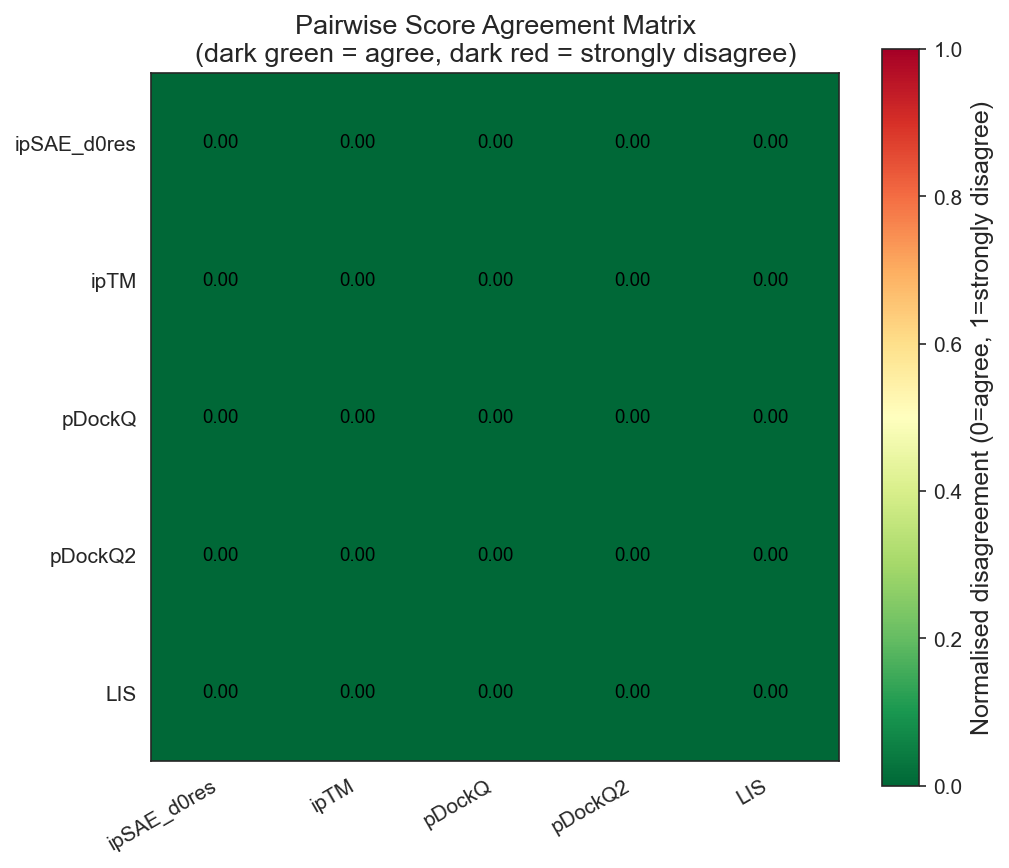

In [43]:
# ── Pairwise agreement matrix ─────────────────────────────────────────────────
score_names = ['ipSAE_d0res', 'ipTM', 'pDockQ', 'pDockQ2', 'LIS']
score_vals  = {n: scores[n] for n in score_names}

# Normalise each score to [0,1] using its green threshold as "1"
norm_scores = {}
for n in score_names:
    g, _ = thresholds[n]
    norm_scores[n] = min(score_vals[n] / g, 1.5)  # cap at 1.5 for display

# Build agreement matrix: |norm_i - norm_j|
n_s = len(score_names)
agree_matrix = np.zeros((n_s, n_s))
for i, ni in enumerate(score_names):
    for j, nj in enumerate(score_names):
        agree_matrix[i, j] = abs(norm_scores[ni] - norm_scores[nj])

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(agree_matrix, cmap='RdYlGn_r', vmin=0, vmax=1)
plt.colorbar(im, ax=ax, label='Normalised disagreement (0=agree, 1=strongly disagree)')
ax.set_xticks(range(n_s))
ax.set_yticks(range(n_s))
ax.set_xticklabels(score_names, rotation=30, ha='right')
ax.set_yticklabels(score_names)
for i in range(n_s):
    for j in range(n_s):
        ax.text(j, i, f'{agree_matrix[i,j]:.2f}', ha='center', va='center',
                fontsize=9, color='black')
ax.set_title('Pairwise Score Agreement Matrix\n'
             '(dark green = agree, dark red = strongly disagree)')
plt.tight_layout()
plt.show()

In [44]:
# ── Plain-text diagnostic statement ──────────────────────────────────────────
ipsae_val  = scores['ipSAE_d0res']
iptm_val   = scores['ipTM']
pdockq_val = scores['pDockQ']
pdockq2_val= scores['pDockQ2']
lis_val    = scores['LIS']

GREEN_IPSAE  = thresholds['ipSAE_d0res'][0]
GREEN_IPTM   = thresholds['ipTM'][0]
GREEN_PDOCKQ = thresholds['pDockQ'][0]
GREEN_LIS    = thresholds['LIS'][0]

tl_ipsae  = traffic_light(ipsae_val,   GREEN_IPSAE,  GREEN_IPSAE/2)[0]
tl_iptm   = traffic_light(iptm_val,    GREEN_IPTM,   GREEN_IPTM/2)[0]
tl_pdockq = traffic_light(pdockq_val,  GREEN_PDOCKQ, GREEN_PDOCKQ/2)[0]
tl_pdockq2= traffic_light(pdockq2_val, thresholds['pDockQ2'][0], thresholds['pDockQ2'][1])[0]
tl_lis    = traffic_light(lis_val,     GREEN_LIS,    GREEN_LIS/2)[0]

# Apply diagnostic heuristics
statements = []

n_green = sum(1 for t in [tl_ipsae, tl_iptm, tl_pdockq, tl_pdockq2, tl_lis]
              if t == 'green')
n_red   = sum(1 for t in [tl_ipsae, tl_iptm, tl_pdockq, tl_pdockq2, tl_lis]
              if t == 'red')

if n_green >= 4:
    statements.append(
        'OVERALL: This complex has consistently HIGH confidence across all metrics. '
        'The interface is well-resolved (high pLDDT), structurally plausible (high pDockQ), '
        'and the PAE matrix shows strong inter-chain confidence.')
elif n_red >= 4:
    statements.append(
        'OVERALL: This complex has LOW confidence across most metrics. '
        'The predicted interaction may be unreliable. Treat structural conclusions with caution.')
else:
    statements.append(
        'OVERALL: Mixed confidence signals — scores disagree. See details below.')

# ipSAE high, pDockQ low
if tl_ipsae == 'green' and tl_pdockq in ('amber', 'red'):
    statements.append(
        'PAE vs STRUCTURE: AlphaFold is confident about relative chain positioning (PAE; '
        f'ipSAE={ipsae_val:.3f}), but there are few physical contacts at the interface '
        f'(pDockQ={pdockq_val:.3f}). This can occur when chains interact via a small, '
        'tight interface or when the predicted inter-chain distance is slightly too large '
        'for contacts to form under the 8 A cutoff.')

# pDockQ high, ipSAE low
if tl_pdockq == 'green' and tl_ipsae in ('amber', 'red'):
    statements.append(
        'STRUCTURE vs PAE: The interface has many contacts between well-resolved residues '
        f'(pDockQ={pdockq_val:.3f}), but AlphaFold PAE indicates uncertainty about the '
        f'relative chain arrangement (ipSAE={ipsae_val:.3f}). The local structure of each '
        'chain may be well-predicted even though the docking orientation is uncertain.')

# pDockQ2 vs pDockQ
pdockq_norm  = pdockq_val  / thresholds['pDockQ'][0]
pdockq2_norm = pdockq2_val / thresholds['pDockQ2'][0]
if abs(pdockq_norm - pdockq2_norm) > 0.4:
    direction = 'pDockQ2 < pDockQ' if pdockq2_norm < pdockq_norm else 'pDockQ2 > pDockQ'
    statements.append(
        f'pDockQ vs pDockQ2 ({direction}): These two scores diverge, indicating that '
        'although physical contacts exist, the PAE confidence at those specific contact '
        'points is '
        + ('low' if pdockq2_norm < pdockq_norm else 'high') +
        '. pDockQ2 incorporates PAE at the interface and is the more informative of the two.')

# LIS high but ipSAE low
if tl_lis == 'green' and tl_ipsae in ('amber', 'red'):
    statements.append(
        f'LIS vs ipSAE: Many inter-chain PAE values are below {LIS_CUTOFF:.0f} A (LIS='
        f'{lis_val:.3f}), but when the cutoff is tightened to {PAE_CUTOFF:.0f} A and the '
        f'TM-score formula is applied (ipSAE={ipsae_val:.3f}), confidence drops. '
        'This suggests a broad but diffuse interaction rather than a tight, '
        'well-defined interface.')

# Print statements
print('=' * 65)
print('DIAGNOSTIC INTERPRETATION')
print('=' * 65)
for s in statements:
    import textwrap
    wrapped = textwrap.fill(s, width=63)
    print()
    print(wrapped)
print()
print('─' * 65)
print('Score summary:')
for name in score_names:
    tl = traffic_light(scores[name], thresholds[name][0], thresholds[name][1])[1]
    print(f'  {name:18s}: {scores[name]:.4f}  [{tl}]')
print('─' * 65)
print('Interface statistics:')
print(f'  Contact pairs     : {n_contacts}')
print(f'  Interface res (A) : {n_if_A}')
print(f'  Interface res (B) : {n_if_B}')
print(f'  Mean pLDDT (if)   : {if_plddt.mean():.1f}')
print(f'  Low pLDDT (<70) if: {n_low_if} / {len(if_plddt)}')
print('=' * 65)
print()
print('References:')
print('  ipSAE : Dunbrack Lab (2025) biorxiv 2025.02.10.637595')
print('  pDockQ: Bryant et al. (2022) Nat Commun s41467-022-28865-w')
print('  pDockQ2: Zhu et al. (2023) Bioinformatics btad424')
print('  LIS   : Kim et al. (2024) biorxiv 2024.02.19.580970')

DIAGNOSTIC INTERPRETATION

OVERALL: This complex has consistently HIGH confidence across
all metrics. The interface is well-resolved (high pLDDT),
structurally plausible (high pDockQ), and the PAE matrix shows
strong inter-chain confidence.

pDockQ vs pDockQ2 (pDockQ2 > pDockQ): These two scores diverge,
indicating that although physical contacts exist, the PAE
confidence at those specific contact points is high. pDockQ2
incorporates PAE at the interface and is the more informative
of the two.

─────────────────────────────────────────────────────────────────
Score summary:
  ipSAE_d0res       : 0.9143  [HIGH]
  ipTM              : 0.9529  [HIGH]
  pDockQ            : 0.6913  [HIGH]
  pDockQ2           : 0.9269  [HIGH]
  LIS               : 0.7564  [HIGH]
─────────────────────────────────────────────────────────────────
Interface statistics:
  Contact pairs     : 116
  Interface res (A) : 43
  Interface res (B) : 43
  Mean pLDDT (if)   : 98.0
  Low pLDDT (<70) if: 0 / 86

References:
 